# TP1: Análisis y Visualización de Datos

Autores: Ana Paula Cobresí, Gonzalo Angaut, Javier Albiero y Octavio Santi.

## Introducción

Primer trabajo práctico de la mentoría «Predicciones en el Espacio: ¿Cuántos satélites y desechos podremos tener?». Exploramos la composición de un catálogo histórico de objetos espaciales y sus variables orbitales, fechas y países o entidades asociados.

Esta revisión conserva los análisis del trabajo original y precisa su alcance: **cada fila representa un objeto catalogado, no un lanzamiento ni necesariamente un objeto que siga en órbita o esté operativo**. Los conteos incluyen registros con reentrada (`DECAY`) informada. Los valores orbitales son los registrados en la fuente; no constituyen una trayectoria temporal.

Las preguntas descriptivas son: ¿qué tipos de objetos aparecen?, ¿cómo se distribuyen por rango de perigeo, categoría de tamaño radar y país o entidad?, ¿a qué años de lanzamiento se asocian? Esta etapa no estima todavía una población orbital futura.


Los cuatro archivos JSON (`satellites.json`, `debris.json`, `rockets.json` y `unknown.json`) comparten estructura y contienen PAYLOAD, DEBRIS, ROCKET BODY y UNKNOWN, respectivamente. La base UCS aporta atributos complementarios de satélites.

Usamos una [versión histórica fija de los cinco archivos](https://github.com/EnzoRg/space_debris/tree/1c49c73b92e84d3eba2c53f43313ed861d08f896/data/raw), porque las rutas originales de `main` cambiaron. El identificador del commit fija los bytes de entrada; **su fecha no equivale a la fecha de observación de cada registro**. Las fuentes pueden tener distintas fechas de corte.

`RCS_SIZE` es una categoría basada en sección radar, utilizada aquí como indicador aproximado de tamaño; no es una medida directa de diámetro o masa. `COUNTRY` se interpreta como país o entidad asociado en el catálogo, no como prueba de responsabilidad por una fragmentación.

Referencias de interpretación: [Space-Track](https://www.space-track.org/documentation), [UCS](https://www.ucs.org/resources/satellite-database) y [tipos de órbitas de ESA](https://www.esa.int/Enabling_Support/Space_Transportation/Types_of_orbits).


## Inspección de los datos

Importamos las librerías necesarias para el análisis y visualización de los datos.

In [1]:
# Sólo para Colab, Anaconda lo provee localmente
#%pip install openpyxl

import seaborn as sns
import pandas as pd
from pandas import DataFrame, Series
from matplotlib import pyplot as plt
from typing import Sequence
from enum import Enum
from pathlib import Path
from urllib.request import urlretrieve

pd.options.mode.copy_on_write = True
pd.options.display.max_columns = None
sns.set_theme(style="whitegrid")


Comencemos leyendo los archivos y mostrando las primeras filas para visualizar la forma de los datos.

In [2]:
# Ejecutar desde esta carpeta. Sólo la primera ejecución necesita descargar los datos.
DATA_COMMIT = "1c49c73b92e84d3eba2c53f43313ed861d08f896"
DATA_URL = f"https://raw.githubusercontent.com/EnzoRg/space_debris/{DATA_COMMIT}/data/raw"
DATA_DIR = Path("data/raw") / DATA_COMMIT
DATA_DIR.mkdir(parents=True, exist_ok=True)

def data_path(filename):
    path = DATA_DIR / filename
    if not path.exists():
        temporary = path.with_suffix(path.suffix + ".part")
        urlretrieve(f"{DATA_URL}/{filename}", temporary)
        temporary.replace(path)
    return path

satellites_df = pd.read_json(data_path("satellites.json"))
debris_df = pd.read_json(data_path("debris.json"))
rockets_df = pd.read_json(data_path("rockets.json"))
unknown_df = pd.read_json(data_path("unknown.json"))
extra_data_df = pd.read_excel(data_path("ucs-satellite-database.xlsx"))
satellites_df.head(3)


Out[2]: 
     INTLDES  NORAD_CAT_ID OBJECT_TYPE     SATNAME COUNTRY      LAUNCH   SITE  \
0  1958-001A             4     PAYLOAD  EXPLORER 1      US  1958-02-01  AFETR   
1  1958-003A             6     PAYLOAD  EXPLORER 3      US  1958-03-26  AFETR   
2  1958-004B             8     PAYLOAD   SPUTNIK 3     CIS  1958-05-15  TTMTR   

        DECAY  PERIOD  INCLINATION  APOGEE  PERIGEE COMMENT  COMMENTCODE  \
0  1970-03-31   88.48        33.15   215.0    183.0    None          NaN   
1  1958-06-28  103.60        33.50  1739.0    117.0    None          5.0   
2  1960-04-06   88.43        65.06   255.0    139.0    None          NaN   

   RCSVALUE RCS_SIZE  FILE  LAUNCH_YEAR  LAUNCH_NUM LAUNCH_PIECE CURRENT  \
0         0     None     1         1958           1            A       Y   
1         0     None     1         1958           3            A       Y   
2         0    LARGE     1         1958           4            B       Y   

  OBJECT_NAME  OBJECT_ID  OBJECT_NUMBER  
0  EXPLORER 1 

In [3]:
# O las primeras columnas del debris
debris_df[:3]

Out[3]: 
     INTLDES  NORAD_CAT_ID OBJECT_TYPE            SATNAME COUNTRY      LAUNCH  \
0  1960-003C            33      DEBRIS  THOR ABLESTAR DEB      US  1960-04-13   
1  1960-005D            37      DEBRIS      SPUTNIK 4 DEB     CIS  1960-05-15   
2  1960-005E            38      DEBRIS      SPUTNIK 4 DEB     CIS  1960-05-15   

    SITE       DECAY  PERIOD  INCLINATION  APOGEE  PERIGEE COMMENT  \
0  AFETR  1960-07-17   93.59        51.29   615.0    285.0    None   
1  TTMTR  1961-06-30   92.92        64.89   552.0    282.0    None   
2  TTMTR  1960-08-20   90.63        64.89   328.0    282.0    None   

   COMMENTCODE  RCSVALUE RCS_SIZE  FILE  LAUNCH_YEAR  LAUNCH_NUM LAUNCH_PIECE  \
0          NaN         0     None     1         1960           3            C   
1          NaN         0     None     1         1960           5            D   
2          NaN         0     None     1         1960           5            E   

  CURRENT        OBJECT_NAME  OBJECT_ID  OBJECT_NUMBER  
0  

### Unificación de los _datasets_

Como todos tienen la misma estructura, y el tipo de objeto puede saberse desde 'OBJECT_TYPE', podemos concatenarlos en un solo DataFrame.

In [4]:
# Veamos que cada archivo tenga su propio OBJECT_TYPE
print(satellites_df.OBJECT_TYPE.unique())
print(debris_df.OBJECT_TYPE.unique())
print(rockets_df.OBJECT_TYPE.unique())
print(unknown_df.OBJECT_TYPE.unique())

['PAYLOAD']
['DEBRIS']
['ROCKET BODY']
['UNKNOWN']


In [5]:
# Los concatenamos en un solo DataFrame
space_objects_df = pd.concat([satellites_df, debris_df, rockets_df, unknown_df], ignore_index=True)

# Vemos el dataframe
space_objects_df.sample(5, random_state=42)


Out[5]: 
         INTLDES  NORAD_CAT_ID  OBJECT_TYPE        SATNAME COUNTRY  \
1786   1990-069A         20732      PAYLOAD    COSMOS 2089     CIS   
11524  2022-101S         53543      PAYLOAD  STARLINK-4297      US   
56130  1966-092C          2505  ROCKET BODY    SL-6 R/B(1)     CIS   
5068   2007-013A         31135      PAYLOAD          AGILE      IT   
53035  2015-075H         41547       DEBRIS   BREEZE-M DEB     CIS   

           LAUNCH   SITE       DECAY   PERIOD  INCLINATION   APOGEE  PERIGEE  \
1786   1990-08-03  PKMTR  1990-10-01    88.72        62.82    257.0    165.0   
11524  2022-08-19  AFETR        None    95.44        53.22    541.0    539.0   
56130  1966-10-20  TTMTR  1966-11-02    90.40        64.80    390.0    195.0   
5068   2007-04-23    SRI  2024-02-13    88.44         2.46    199.0    195.0   
53035  2015-12-13  TTMTR        None  1395.48         7.66  36071.0  33904.0   

      COMMENT  COMMENTCODE  RCSVALUE RCS_SIZE  FILE  LAUNCH_YEAR  LAUNCH_NUM  \
1786     

In [6]:
# Veamos que el tamaño del nuevo df es igual a la suma de los anteriores
satellites_df.shape[0]+debris_df.shape[0]+rockets_df.shape[0]+unknown_df.shape[0] == space_objects_df.shape[0]

Out[6]: True


### Calidad básica y alcance del catálogo

Contamos faltantes y reentradas registradas por tipo. No imputamos atributos en esta etapa exploratoria. Una fecha de reentrada ausente no es una etiqueta de actividad.


In [7]:
quality = space_objects_df.groupby('OBJECT_TYPE').agg(
    Registros=('NORAD_CAT_ID', 'size'),
    Con_reentrada=('DECAY', 'count'),
    Con_perigeo=('PERIGEE', 'count'),
    Con_tamano_radar=('RCS_SIZE', 'count'),
)
quality['Sin_reentrada_registrada'] = quality['Registros'] - quality['Con_reentrada']
display(quality)
display(space_objects_df[['NORAD_CAT_ID', 'COUNTRY', 'LAUNCH_YEAR', 'DECAY', 'PERIGEE', 'APOGEE', 'RCS_SIZE']].isna().mean().mul(100).rename('Faltantes (%)').round(2).to_frame())
assert space_objects_df['NORAD_CAT_ID'].notna().all()
assert space_objects_df['NORAD_CAT_ID'].is_unique


,Registros,Con_reentrada,Con_perigeo,Con_tamano_radar,Sin_reentrada_registrada
OBJECT_TYPE,,,,,
DEBRIS,35606,22672,35262,29537,12934
PAYLOAD,20328,6142,19919,18017,14186
ROCKET BODY,6699,4325,6479,4723,2374
UNKNOWN,888,303,888,871,585


,Faltantes (%)
NORAD_CAT_ID,0.00
COUNTRY,0.00
LAUNCH_YEAR,0.00
DECAY,47.35
PERIGEE,1.53
APOGEE,1.53
RCS_SIZE,16.33


## Integración de los datos

### Categoría de tamaño radar y etiquetas orbitales

`RCS_SIZE` permite explorar categorías de tamaño radar. UCS incluye `Class of Orbit` y `Type of Orbit`, pero su cobertura no es la misma que la del catálogo histórico. Antes de usar esas etiquetas, examinamos la unión mediante el identificador NORAD.


In [8]:
extra_data_df[:3]

Out[8]: 
                  Name of Satellite, Alternate Names  \
0  1HOPSAT-TD (1st-generation High Optical Perfor...   
1                            AAC AIS-Sat1 (Kelpie 1)   
2                                           Aalto-1    

  Current Official Name of Satellite Country/Org of UN Registry  \
0                         1HOPSAT-TD                         NR   
1            AAC AIS-Sat1 (Kelpie 1)             United Kingdom   
2                            Aalto-1                    Finland   

  Country of Operator/Owner    Operator/Owner       Users  \
0                       USA      Hera Systems  Commercial   
1            United Kingdom   AAC Clyde Space  Commercial   
2                   Finland  Aalto University       Civil   

                  Purpose                       Detailed Purpose  \
0       Earth Observation                       Infrared Imaging   
1       Earth Observation  Automatic Identification System (AIS)   
2  Technology Development                       

Por lo tanto, un primer paso sería combinar los dataframes. Para esto, notar que en el df de space objects tenemos la columna "NORAD_CAT_ID" mientras que en el extra la columna "NORAD Number", y ambas contien el identificador único asignado por NORAD.

In [9]:
space_objects_df['NORAD_CAT_ID'].sample(5, random_state=42)


Out[9]: 
1786     20732
11524    53543
56130     2505
5068     31135
53035    41547
Name: NORAD_CAT_ID, dtype: int64


In [10]:
extra_data_df['NORAD Number'].sample(5, random_state=42)


Out[10]: 
6882    56035
6237    53913
263     55011
694     45608
2264    49285
Name: NORAD Number, dtype: int64


Antes de unir los dataframes (o agregar las columnas relevantes de extra_data a satellites, etc) veamos que los identificadores son realmente únicos.

In [11]:
print("Duplicados en space objects: ", space_objects_df['NORAD_CAT_ID'].duplicated().sum())
print("Duplicados en extra_data: ", extra_data_df['NORAD Number'].duplicated().sum())

Duplicados en space objects:  0
Duplicados en extra_data:  9


Notemos que el único que contiene identificadores duplicados es `extra_data_df`. Por ende, antes de unirlos, exploremos como son estos datos.

In [12]:
# Cantidad de filas totalmente duplicadas (incluyendo NORAD Number y demás)
exact_duplicates = extra_data_df.duplicated()
exact_duplicates.sum()

Out[12]: np.int64(7)


Hay 7 filas que están completamente duplicadas. Por lo tanto, podemos eliminar los duplicados y quedarnos unicamente con 1 de esos.

In [13]:
extra_data_clean_df = extra_data_df.drop_duplicates()
extra_data_clean_df['NORAD Number'].duplicated().sum()

Out[13]: np.int64(2)


Quedan 2 filas que tienen el mismo 'NORAD Number' pero no estan completamente duplicados. Veamos estas.

In [14]:
# Veamos los NORAD Numbers que siguen estando duplicados en extra_data_clean
remaining_dupes = extra_data_clean_df['NORAD Number'][extra_data_clean_df['NORAD Number'].duplicated()].unique()

# Vemos los nombres de los satelites en esos NORAD Numbers
space_obj_names_df = space_objects_df[space_objects_df['NORAD_CAT_ID'].isin(remaining_dupes)][['NORAD_CAT_ID', 'SATNAME']]
print(space_obj_names_df)

# Vemos los nombres de los extra_data_clean en los duplicados
extra_dupes_df = extra_data_clean_df[extra_data_clean_df['NORAD Number'].isin(remaining_dupes)][
    ['NORAD Number', 'Name of Satellite, Alternate Names']
]
print(extra_dupes_df)

       NORAD_CAT_ID        SATNAME
11757         54766  STARLINK-5471
11826         55455  STARLINK-5680
      NORAD Number Name of Satellite, Alternate Names
6621         54766                     Starlink-5471 
6622         54766                     Starlink-5472 
6744         55455      Starlink-5636                
6787         55455      Starlink-5680                


Para estos dos identificadores conservamos la fila cuyo nombre coincide con `SATNAME`, después de quitar espacios. Es una regla de resolución documentada para esta versión del dataset; la coincidencia de nombres no valida por sí sola todos los demás atributos ni corrige los identificadores de las filas descartadas.


In [15]:
# Creamos un diccionario de NORAD: nombre correcto
norad_correct_names = {
    54766: 'Starlink-5471',
    55455: 'Starlink-5680',
}

def keep_if_name_matches(row: Series) -> bool:
    """
    Función para filtrar las filas correctas
    """
    norad = row['NORAD Number']
    name = str(row['Name of Satellite, Alternate Names']).strip()

    # Si la fila tiene NORAD que aparece duplicado
    if norad in norad_correct_names:
        # Devolvemos el nombre correcto
        return name == norad_correct_names[norad]

    return True  # no es un NORAD conflictivo, lo dejamos

# Aplicamos el filtro
final_extra_data_df = extra_data_clean_df[extra_data_clean_df.apply(keep_if_name_matches, axis=1)]

# Chequeamos que ahora no haya duplicados en el final_extra_data
print("Duplicados en final_extra_data: ", final_extra_data_df['NORAD Number'].duplicated().sum())

Duplicados en final_extra_data:  0


Ahora que ya tenemos el _dataframe_ de datos extras sin duplicados, podemos hacer el merge tranquilamente.

In [16]:
# Elegimos las columnas relevantes
# Conservamos los nombres originales para facilitar la comparación con UCS.
relevant_cols = ['NORAD Number', 'Class of Orbit', 'Type of Orbit'] # agregar más si es necesario
final_extra_data_small_df = final_extra_data_df[relevant_cols]

space_objects_full_df = space_objects_df.merge(
    final_extra_data_small_df,
    how='left',
    left_on='NORAD_CAT_ID',
    right_on='NORAD Number',
    validate='one_to_one',
    indicator='UCS_MATCH'
)
space_objects_full_df.sample(5, random_state=42)


Out[16]: 
         INTLDES  NORAD_CAT_ID  OBJECT_TYPE        SATNAME COUNTRY  \
1786   1990-069A         20732      PAYLOAD    COSMOS 2089     CIS   
11524  2022-101S         53543      PAYLOAD  STARLINK-4297      US   
56130  1966-092C          2505  ROCKET BODY    SL-6 R/B(1)     CIS   
5068   2007-013A         31135      PAYLOAD          AGILE      IT   
53035  2015-075H         41547       DEBRIS   BREEZE-M DEB     CIS   

           LAUNCH   SITE       DECAY   PERIOD  INCLINATION   APOGEE  PERIGEE  \
1786   1990-08-03  PKMTR  1990-10-01    88.72        62.82    257.0    165.0   
11524  2022-08-19  AFETR        None    95.44        53.22    541.0    539.0   
56130  1966-10-20  TTMTR  1966-11-02    90.40        64.80    390.0    195.0   
5068   2007-04-23    SRI  2024-02-13    88.44         2.46    199.0    195.0   
53035  2015-12-13  TTMTR        None  1395.48         7.66  36071.0  33904.0   

      COMMENT  COMMENTCODE  RCSVALUE RCS_SIZE  FILE  LAUNCH_YEAR  LAUNCH_NUM  \
1786    

In [17]:
# Verificamos que la unión conserva las filas (incluye columnas UCS e indicador).
print("Tamaño del original: ", space_objects_df.shape)
print("Tamaño del merged: ", space_objects_full_df.shape)
assert len(space_objects_full_df) == len(space_objects_df)

coverage = space_objects_full_df.assign(MATCHED=space_objects_full_df["UCS_MATCH"].eq("both")).groupby("OBJECT_TYPE")["MATCHED"].agg(["size", "sum"])
coverage.columns = ["Registros", "Coincidencias UCS"]
coverage["Cobertura (%)"] = 100 * coverage["Coincidencias UCS"] / coverage["Registros"]
display(coverage.round(2))


Tamaño del original:  (63521, 24)
Tamaño del merged:  (63521, 28)


,Registros,Coincidencias UCS,Cobertura (%)
OBJECT_TYPE,,,
DEBRIS,35606,15,0.04
PAYLOAD,20328,7369,36.25
ROCKET BODY,6699,7,0.10
UNKNOWN,888,160,18.02


In [18]:
# Notemos que los datos extra casi siempre son sólo para los satélites (capaz podriamos
# haber agregado la info extra sólo a satellites NORADs del UCS)
norads_extra = set(final_extra_data_df['NORAD Number'])

# NORADs de cada dataset
norads_sat = set(satellites_df['NORAD_CAT_ID'])
norads_debris = set(debris_df['NORAD_CAT_ID'])
norads_rockets = set(rockets_df['NORAD_CAT_ID'])
norads_unknown = set(unknown_df['NORAD_CAT_ID'])

print("NORADs en UCS:", len(norads_extra))
print("Coincidencias con satellites:", len(norads_extra & norads_sat))
print("Coincidencias con debris:", len(norads_extra & norads_debris))
print("Coincidencias con rockets:", len(norads_extra & norads_rockets))
print("Coincidencias con unknown:", len(norads_extra & norads_unknown))

NORADs en UCS: 7551
Coincidencias con satellites: 7369
Coincidencias con debris: 15
Coincidencias con rockets: 7
Coincidencias con unknown: 160


La unión aporta 7.551 coincidencias: 7.369 PAYLOAD, 15 DEBRIS, 7 ROCKET BODY y 160 UNKNOWN. Las 182 coincidencias fuera de PAYLOAD requieren revisar las clasificaciones y fechas de ambas fuentes; no las reinterpretamos automáticamente como satélites operativos.

Para conservar el alcance del trabajo original, los gráficos siguientes usan el catálogo completo `space_objects_df`. UCS queda como fuente complementaria, con cobertura explicitada. No extendemos sus etiquetas a los objetos sin coincidencia.


## Análisis y Visualización de los datos

Exploramos la composición del catálogo histórico por tipo de objeto y **rango de perigeo registrado**. Conservamos los cortes aproximados del trabajo original, pero evitamos llamarlos clases orbitales: una órbita elíptica puede tener perigeo bajo y apogeo alto; identificar una órbita geoestacionaria requiere más información.

Los intervalos son continuos, sin huecos entre valores decimales. Los registros con perigeo faltante o negativo se informan por separado. El rango cercano a la altura GEO usa la tolerancia exploratoria original de ±1.000 km; no valida pertenencia a GEO.


In [19]:
class PerigeeBand(Enum):
    """Intervalos [límite inferior, límite superior), en km."""
    BELOW_160 = (0, 160)
    FROM_160_TO_2000 = (160, 2_000)
    FROM_2000_TO_34786 = (2_000, 34_786)
    FROM_34786_TO_36786 = (34_786, 36_786)
    ABOVE_36786 = (36_786, float('inf'))

perigee_labels = {
    "BELOW_160": "0–<160 km",
    "FROM_160_TO_2000": "160–<2.000 km",
    "FROM_2000_TO_34786": "2.000–<34.786 km",
    "FROM_34786_TO_36786": "34.786–<36.786 km",
    "ABOVE_36786": "≥36.786 km",
}


In [20]:
def get_orbit_df(dataframe: DataFrame, orbit_type: PerigeeBand, decayed: bool | None = None) -> DataFrame:
    """
    Retorna los registros del rango de perigeo. Por defecto incluye todos los objetos,
    con o sin reentrada registrada; decayed permite seleccionar por presencia de DECAY.
    """
    return dataframe[
        (dataframe.PERIGEE >= orbit_type.value[0]) &
        (dataframe.PERIGEE < orbit_type.value[1]) &
        (True if decayed is None else (dataframe.DECAY.notnull() if decayed else dataframe.DECAY.isnull()))
    ]


def plot_pie(data, labels: Sequence[str], title: str | None = None) -> None:
    """
    Función simple para crear un gráfico de torta
    """
    plt.rcParams["figure.figsize"] = (8, 6)
    _, ax = plt.subplots()
    ax.pie(data, labels=labels, autopct='%1.1f%%', textprops={'size': 'smaller'}, radius=1)
    if title is not None:
        plt.title(title)
    plt.show()


def plot_ranking(xseries: Series, yseries: Series, xlabel: str, ylabel: str, title: str | None = None) -> None:
    """
    Función simple para crear un ránking. La serie de valores de Y debe estar ordenada ascendentemente
    """
    plt.figure(figsize=(10, 8))
    bh = plt.barh(yseries, xseries)
    plt.bar_label(bh, fmt=" %.0f")
    plt.ticklabel_format(style='plain', axis='x')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xlim((0, max(xseries) * 1.25))  # 1.25 genera espacio para las etiquetas de cada barra
    if title is not None:
        plt.title(title)
    plt.show()


# Subconjuntos por rango de perigeo registrado.
orbit_df_dic = {
    perigee_labels[band.name]: get_orbit_df(space_objects_df, band) for band in PerigeeBand
}


### Distribución por rango de perigeo

Se incluyen registros históricos con y sin reentrada informada. Las categorías no describen la ocupación orbital actual.


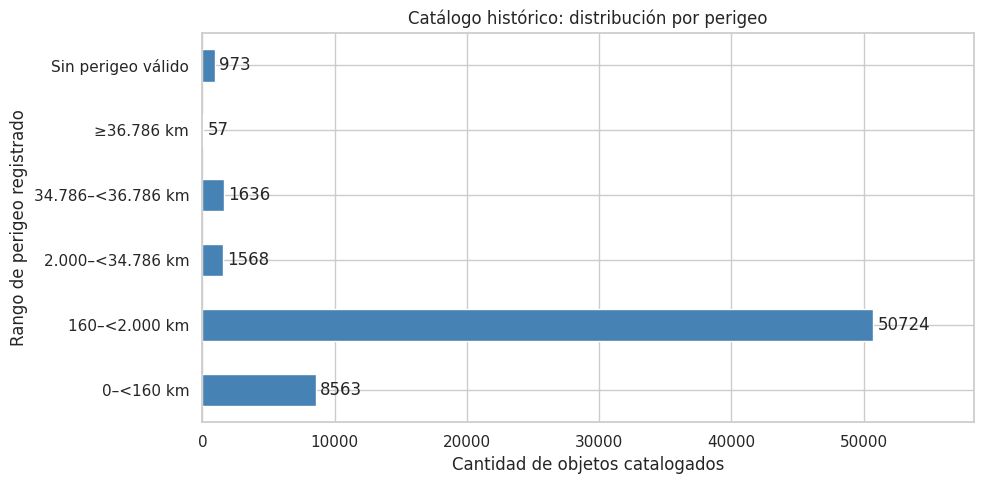

In [21]:
perigee_counts = pd.Series({name: len(df) for name, df in orbit_df_dic.items()})
perigee_counts.loc['Sin perigeo válido'] = len(space_objects_df) - perigee_counts.sum()
assert perigee_counts.sum() == len(space_objects_df)
ax = perigee_counts.plot.barh(figsize=(10, 5), color='steelblue')
ax.bar_label(ax.containers[0], padding=3)
ax.set_xlabel('Cantidad de objetos catalogados')
ax.set_ylabel('Rango de perigeo registrado')
ax.set_title('Catálogo histórico: distribución por perigeo')
ax.set_xlim(0, perigee_counts.max() * 1.15)
plt.tight_layout()
plt.show()


El rango de perigeo de 160 a menos de 2.000 km concentra la mayoría de los registros. Esto no basta para identificar cuántos objetos siguen en LEO ni para atribuir su distribución a una constelación particular.

Examinamos los registros con perigeo menor a 160 km y contamos cuántos tienen reentrada informada.


In [22]:
blo_df = orbit_df_dic["0–<160 km"]

blo_total = len(blo_df)
blo_decayed = len(blo_df[blo_df.DECAY.notnull()])

print("Registros con perigeo <160 km:", blo_total)
print("De ellos, con reentrada registrada:", blo_decayed)


Registros con perigeo <160 km: 8563
De ellos, con reentrada registrada: 8535


La mayoría de los registros de este rango tiene reentrada informada. Este resultado ilustra por qué no debemos interpretar el catálogo completo como una población actualmente en órbita. Ausencia de `DECAY` significa aquí **sin reentrada registrada**, no confirmación de actividad operativa.


### Distribución de los tipos de objeto

Contamos las cuatro categorías del catálogo histórico, incluyendo los registros con reentrada informada.


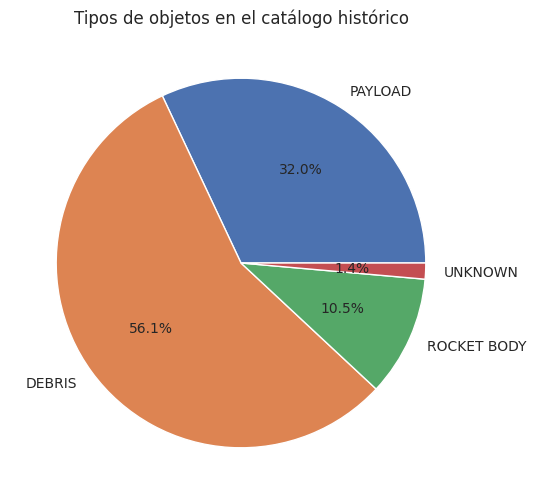

In [23]:
type_dfs = [satellites_df, debris_df, rockets_df, unknown_df]
type_labels = ["PAYLOAD", "DEBRIS", "ROCKET BODY", "UNKNOWN"]


plot_pie(
    data=[len(df) for df in type_dfs],
    labels=type_labels,
    title="Tipos de objetos en el catálogo histórico")


Algo más de la mitad de los registros pertenece a DEBRIS. Es una proporción del catálogo analizado, no una estimación de toda la basura espacial ni de la población actualmente en órbita.


### Relación entre categoría de tamaño radar y rango de perigeo

Mostramos conteos y porcentajes dentro de cada rango. Incluimos explícitamente `Sin dato` en RCS_SIZE para que el denominador no cambie silenciosamente. Estos mapas son tablas de contingencia, no matrices de correlación.


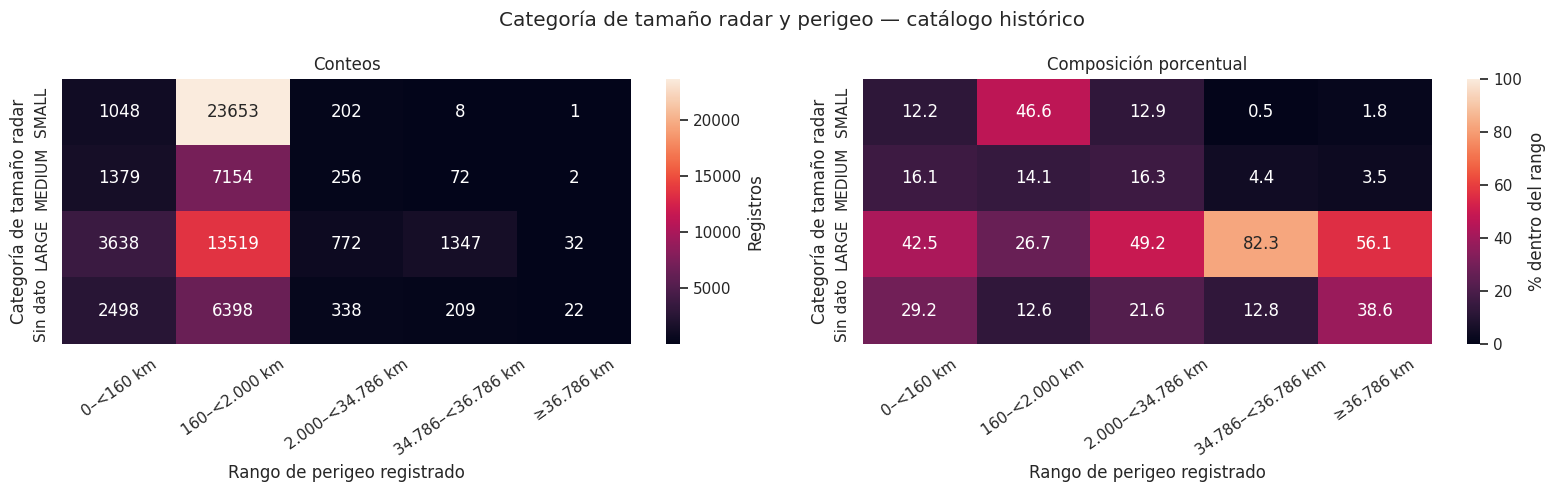

In [24]:
rcs_order_with_missing = ['SMALL', 'MEDIUM', 'LARGE', 'Sin dato']
rcs_orbit_heatmap_data = pd.DataFrame({
    name: df['RCS_SIZE'].fillna('Sin dato').value_counts().reindex(rcs_order_with_missing, fill_value=0)
    for name, df in orbit_df_dic.items()
})
rcs_orbit_percent = rcs_orbit_heatmap_data.div(rcs_orbit_heatmap_data.sum(axis=0).replace(0, float('nan')), axis=1) * 100
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.heatmap(rcs_orbit_heatmap_data, annot=True, fmt='g', ax=axes[0], cbar_kws={'label': 'Registros'})
sns.heatmap(rcs_orbit_percent, annot=True, fmt='.1f', ax=axes[1], vmin=0, vmax=100, cbar_kws={'label': '% dentro del rango'})
for ax, title in zip(axes, ['Conteos', 'Composición porcentual']):
    ax.set_title(title)
    ax.set_xlabel('Rango de perigeo registrado')
    ax.set_ylabel('Categoría de tamaño radar')
    ax.tick_params(axis='x', rotation=35)
fig.suptitle('Categoría de tamaño radar y perigeo — catálogo histórico')
plt.tight_layout()
plt.show()


En el rango de 160–<2.000 km predominan los registros SMALL; en los demás rangos, LARGE es la categoría conocida más frecuente. Los conteos describen volumen y los porcentajes composición. La fila `Sin dato` permite evaluar cuánto limita la falta de información esta comparación.


### Análisis de los objetos clasificados como DEBRIS

Exploramos qué países o entidades tienen más registros asociados de tipo DEBRIS. Incluimos los objetos con reentrada registrada. Estos conteos no miden por sí solos generación actual de basura, masa de residuos ni responsabilidad por colisiones.


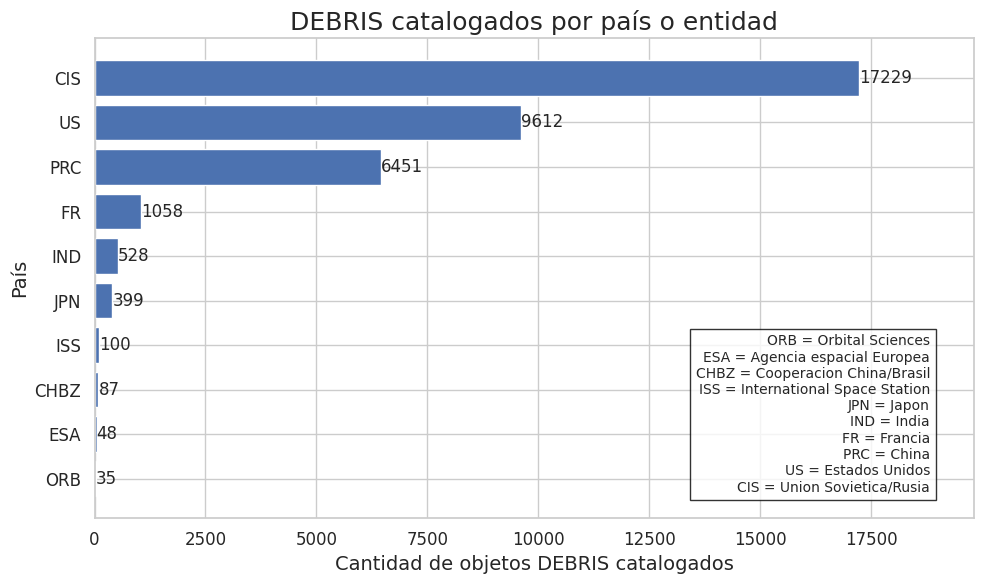

In [25]:
# Filtramos solo los objetos que son desechos espaciales
# Nota de optimización: También se podría haber usado directamente 'debris_df'
debris_only_df = space_objects_df[space_objects_df['OBJECT_TYPE'] == 'DEBRIS']

# Agrupamos por país y contamos la cantidad de desechos por país
debris_per_country_df = debris_only_df.groupby('COUNTRY').size().sort_values(ascending=False)
sorted_debris_per_country = debris_per_country_df.sort_values(ascending=False).head(10).sort_values()

country_names = {
    "CIS": "Union Sovietica/Rusia",
    "US": "Estados Unidos",
    "PRC": "China",
    "FR": "Francia",
    "IND": "India",
    "JPN": "Japon",
    "ISS": "International Space Station",
    "CHBZ": "Cooperacion China/Brasil",
    "ESA": "Agencia espacial Europea",
    "ORB": "Orbital Sciences"
}

def plot_ranking_with_legend(xseries, yseries, xlabel, ylabel, title, legend_map):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(yseries, xseries)
    ax.set_xlim(0, max(xseries) * 1.15)

    # Títulos y etiquetas grandes
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title(title, fontsize=18)

    # Etiquetas de ejes grandes
    ax.tick_params(axis='x', labelsize=12)
    ax.tick_params(axis='y', labelsize=12)

    # Mostrar valores al lado de las barras
    for i, v in enumerate(xseries):
        ax.text(v + 1, i, str(v), fontsize=12, va='center')

    # Crear texto para la leyenda interna
    legend_text = "\n".join([f"{code} = {legend_map.get(code, code)}" for code in yseries])
    ax.text(
        0.95, 0.05, legend_text,
        transform=ax.transAxes,
        fontsize=10,
        va='bottom', ha='right',
        bbox=dict(facecolor='white', alpha=0.8, edgecolor='black')
    )

    plt.tight_layout()
    plt.show()

plot_ranking_with_legend(
    xseries=sorted_debris_per_country.values,
    yseries=sorted_debris_per_country.index,
    xlabel="Cantidad de objetos DEBRIS catalogados",
    ylabel="País",
    title="DEBRIS catalogados por país o entidad",
    legend_map=country_names
)


CIS, US y PRC concentran los mayores conteos de DEBRIS del catálogo. A continuación comparamos esos tres grupos según la década de lanzamiento asociada a cada registro.

**La década de lanzamiento no identifica la década en que se generó un fragmento.** Un objeto puede fragmentarse mucho después del lanzamiento; este gráfico no reconstruye una tasa histórica de generación de basura.


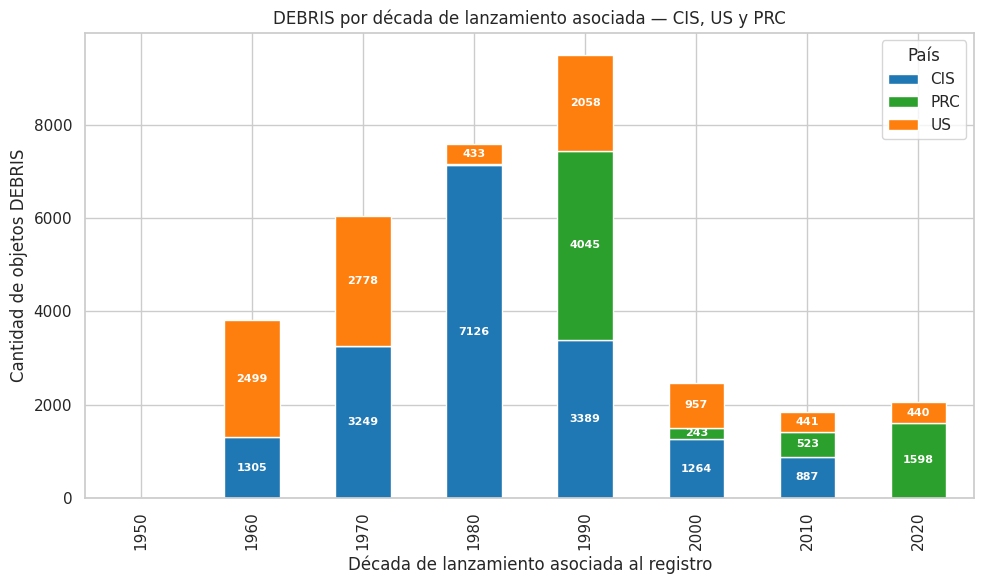

In [26]:
# Filtrar basura espacial y países de interés
selected_countries = ['CIS', 'US', 'PRC']
debris_filtered_df = debris_only_df[debris_only_df['COUNTRY'].isin(selected_countries)].copy()

# Asegurar tipo numérico en LAUNCH_YEAR
debris_filtered_df['LAUNCH_YEAR'] = pd.to_numeric(debris_filtered_df['LAUNCH_YEAR'], errors='coerce')

# Crear columna de década
debris_filtered_df['DECADE'] = (debris_filtered_df['LAUNCH_YEAR'] // 10) * 10

# Agrupar y pivotear: filas = década, columnas = país, valores = cantidad
debris_by_decade_df = (
    debris_filtered_df
    .groupby(['DECADE', 'COUNTRY'])
    .size()
    .reset_index(name='count')
    .pivot(index='DECADE', columns='COUNTRY', values='count')
    .fillna(0)
    .astype(int)
)

colors = {
    'CIS': '#1f77b4',
    'US': '#ff7f0e',
    'PRC': '#2ca02c'
}

ax = debris_by_decade_df.plot(
    kind='bar',
    stacked=True,
    color=[colors[c] for c in debris_by_decade_df.columns],
    figsize=(10, 6)
)

# Agregar etiquetas de valor por país en cada segmento
for i, decade in enumerate(debris_by_decade_df.index):
    y_offset = 0
    for country in debris_by_decade_df.columns:
        value = debris_by_decade_df.loc[decade, country]
        if value >= 200:
            ax.text(
                i, y_offset + value / 2,  # posición del texto
                str(value),
                ha='center', va='center',
                fontsize=8, color='white', fontweight='bold'
            )
        y_offset += value

plt.title('DEBRIS por década de lanzamiento asociada — CIS, US y PRC')
plt.xlabel('Década de lanzamiento asociada al registro')
plt.ylabel('Cantidad de objetos DEBRIS')
plt.legend(title='País')
plt.tight_layout()
plt.show()


Entre los tres grupos seleccionados, los registros asociados a lanzamientos de los años 80 se concentran en CIS, mientras que PRC tiene una participación importante en los asociados a los años 90.

Estos patrones describen cohortes de lanzamiento del catálogo. No permiten concluir cuándo se generó la basura, cuánto invirtió cada país ni cuál fue el efecto de políticas de mitigación. Los porcentajes entre estos tres grupos tampoco equivalen al total mundial y la última década está incompleta.


### Distribuciones de DEBRIS por país y categoría de tamaño radar

Comparamos SMALL, MEDIUM y LARGE entre CIS, US y PRC. Al ser categorías ordinales, usamos barras porcentuales en lugar de estimar una densidad continua sobre los códigos 0, 1 y 2. Los porcentajes siguientes se calculan **entre registros con RCS_SIZE conocido**; también informamos los faltantes.


,Registros,Con_dato,Sin_dato
COUNTRY,,,
CIS,17229,12767,4462
US,9612,8177,1435
PRC,6451,6391,60


RCS_SIZE,SMALL,MEDIUM,LARGE
COUNTRY,,,
CIS,9277,2619,871
US,6485,1553,139
PRC,5786,497,108


RCS_SIZE,SMALL,MEDIUM,LARGE
COUNTRY,,,
CIS,72.7,20.5,6.8
US,79.3,19.0,1.7
PRC,90.5,7.8,1.7


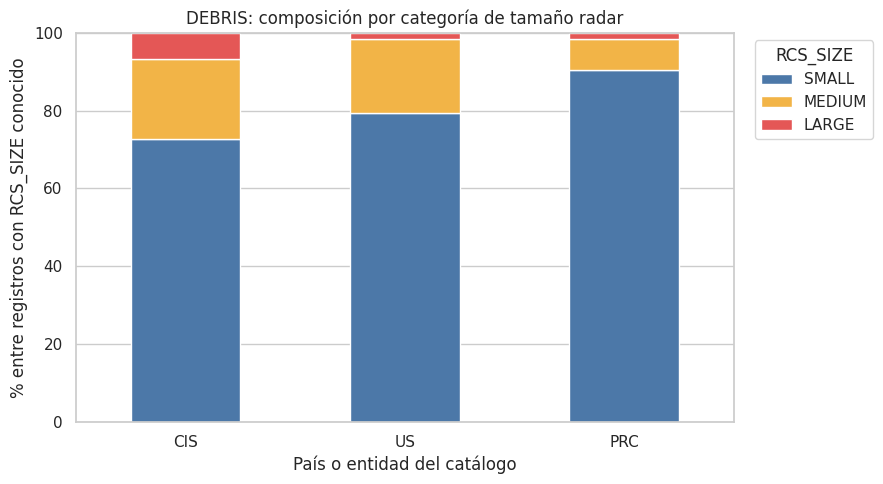

In [27]:
selected_countries = ['CIS', 'US', 'PRC']
top_debris_countries_df = debris_only_df[debris_only_df['COUNTRY'].isin(selected_countries)].copy()
rcs_order = ['SMALL', 'MEDIUM', 'LARGE']
size_distribution = pd.crosstab(top_debris_countries_df['COUNTRY'], top_debris_countries_df['RCS_SIZE']).reindex(index=selected_countries, columns=rcs_order, fill_value=0)
percentage_distribution = size_distribution.div(size_distribution.sum(axis=1), axis=0) * 100
rcs_coverage = top_debris_countries_df.groupby('COUNTRY')['RCS_SIZE'].agg(Registros='size', Con_dato='count').reindex(selected_countries)
rcs_coverage['Sin_dato'] = rcs_coverage['Registros'] - rcs_coverage['Con_dato']
display(rcs_coverage)
display(size_distribution)
display(percentage_distribution.round(1))
ax = percentage_distribution.plot.bar(stacked=True, figsize=(9, 5), color=['#4c78a8', '#f2b447', '#e45756'])
ax.set_title('DEBRIS: composición por categoría de tamaño radar')
ax.set_xlabel('País o entidad del catálogo')
ax.set_ylabel('% entre registros con RCS_SIZE conocido')
ax.set_ylim(0, 100)
ax.tick_params(axis='x', rotation=0)
ax.legend(title='RCS_SIZE', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


SMALL predomina en los tres grupos. Entre registros con tamaño conocido, PRC tiene la mayor proporción SMALL y CIS presenta proporciones MEDIUM y LARGE mayores que US y PRC. Esto compara categorías radar, sin medir la masa total de residuos.

El siguiente mapa muestra los mismos porcentajes como alternativa de lectura.


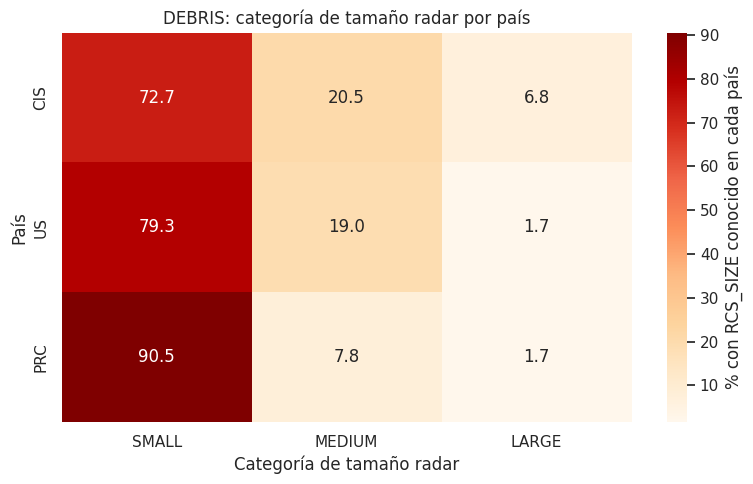

In [28]:
heatmap_data = (
  top_debris_countries_df.groupby(['COUNTRY', 'RCS_SIZE'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=selected_countries, columns=rcs_order, fill_value=0)
)
heatmap_percent = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

# Crear heatmap porcentual
plt.figure(figsize=(8, 5))
sns.heatmap(
    heatmap_percent.round(1),
    annot=True, fmt=".1f", cmap="OrRd",
    cbar_kws={'label': '% con RCS_SIZE conocido en cada país'}
)

plt.title("DEBRIS: categoría de tamaño radar por país")
plt.xlabel("Categoría de tamaño radar")
plt.ylabel("País")
plt.tight_layout()
plt.show()


### Distribución del apogeo de DEBRIS

Usamos los registros DEBRIS de CIS, US y PRC, independientemente de que tengan tamaño radar informado. Para facilitar la lectura mostramos apogeos entre 0 y 40.000 km e informamos los excluidos. Las líneas de referencia de altura no asignan una clase orbital.


Registros mostrados: 32,875 de 33,292
Sin apogeo: 323; fuera del rango: 94


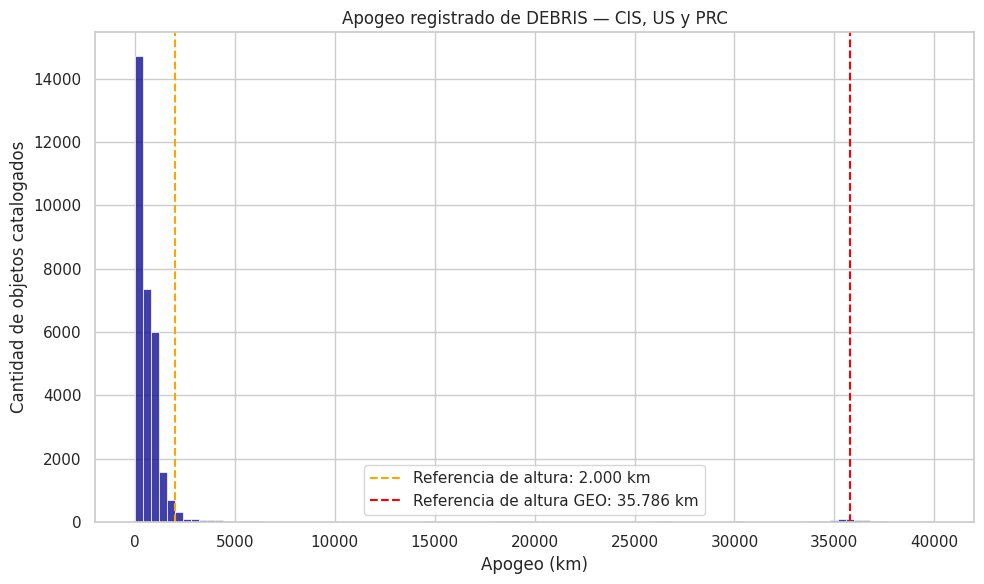

In [29]:
apogee_numeric = pd.to_numeric(top_debris_countries_df['APOGEE'], errors='coerce')
apogee_mask = apogee_numeric.ge(0) & apogee_numeric.lt(40_000)
apogee_data = apogee_numeric[apogee_mask]
print(f'Registros mostrados: {len(apogee_data):,} de {len(apogee_numeric):,}')
print(f'Sin apogeo: {apogee_numeric.isna().sum():,}; fuera del rango: {(apogee_numeric.notna() & ~apogee_mask).sum():,}')
plt.figure(figsize=(10, 6))
sns.histplot(apogee_data, bins=100, color='darkblue')
plt.title('Apogeo registrado de DEBRIS — CIS, US y PRC')
plt.xlabel('Apogeo (km)')
plt.ylabel('Cantidad de objetos catalogados')
plt.axvline(2000, color='orange', linestyle='--', label='Referencia de altura: 2.000 km')
plt.axvline(35786, color='red', linestyle='--', label='Referencia de altura GEO: 35.786 km')
plt.legend()
plt.tight_layout()
plt.show()


Los apogeos representados se concentran en alturas bajas. El histograma describe este subconjunto histórico y el rango mostrado; no mide la distribución orbital actual ni permite fechar eventos de fragmentación. Los registros excluidos y la cobertura temporal deben considerarse antes de generalizar.


### Ránking de objetos catalogados por país o entidad


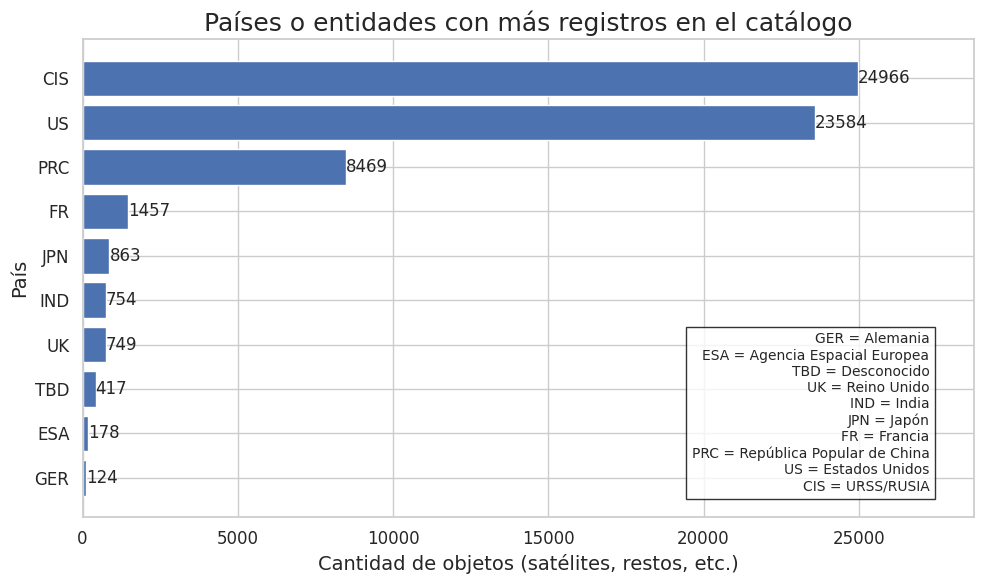

In [30]:
nombres_paises = {
    "CIS": "URSS/RUSIA",
    "US": "Estados Unidos",
    "PRC": "República Popular de China",
    "FR": "Francia",
    "JPN": "Japón",
    "IND": "India",
    "UK": "Reino Unido",
    "TBD": "Desconocido",
    "ESA": "Agencia Espacial Europea",
    "GER": "Alemania"

}


# Filtrar top 10
objs_per_country_df = (
    space_objects_df
    .groupby("COUNTRY")
    .count()
    .sort_values("OBJECT_ID", ascending=False)
    .head(10)
    .sort_values("OBJECT_ID", ascending=True)
)

plot_ranking_with_legend(
    xseries=objs_per_country_df.OBJECT_ID,
    yseries=objs_per_country_df.index,
    xlabel="Cantidad de objetos (satélites, restos, etc.)",
    ylabel="País",
    title="Países o entidades con más registros en el catálogo",
    legend_map=nombres_paises
)


### Distribución conjunta de tamaño radar y tipo de objeto


La tabla siguiente muestra conteos por categoría de tamaño radar y tipo de objeto, incluyendo tamaños faltantes. Es una tabla de contingencia; no cuantifica por sí sola la fuerza de una asociación.


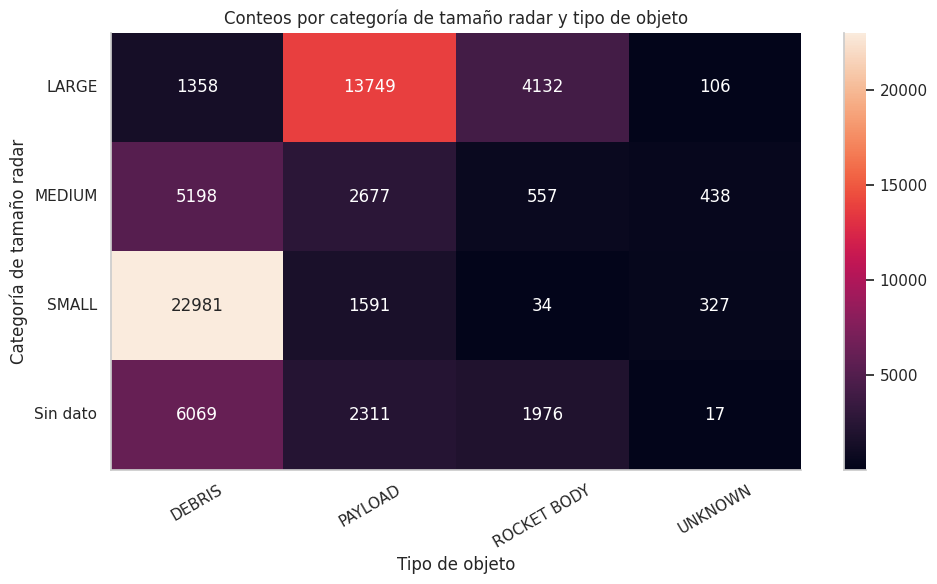

In [31]:
# Creamos la tabla cruzada
obj_size_vs_type_df = pd.crosstab(space_objects_df['RCS_SIZE'].fillna('Sin dato'), space_objects_df['OBJECT_TYPE'])

# Graficamos
plt.figure(figsize=(10, 6))
sns.heatmap(obj_size_vs_type_df, annot=True, fmt='g') # mapa de calor
plt.title('Conteos por categoría de tamaño radar y tipo de objeto')
plt.xlabel('Tipo de objeto')
plt.ylabel('Categoría de tamaño radar')
plt.xticks(rotation=30)
plt.yticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()


Entre los registros con tamaño informado, DEBRIS se concentra en SMALL y PAYLOAD y ROCKET BODY en LARGE. UNKNOWN aparece en varias categorías. La presencia de tamaños faltantes limita la comparación y no debe confundirse con una categoría física adicional.


### Objetos no clasificados como DEBRIS

Repetimos el análisis por país excluyendo únicamente DEBRIS. **No llamamos activos a estos objetos:** el filtro conserva PAYLOAD, ROCKET BODY y UNKNOWN, sin determinar su estado operativo ni excluir reentradas.


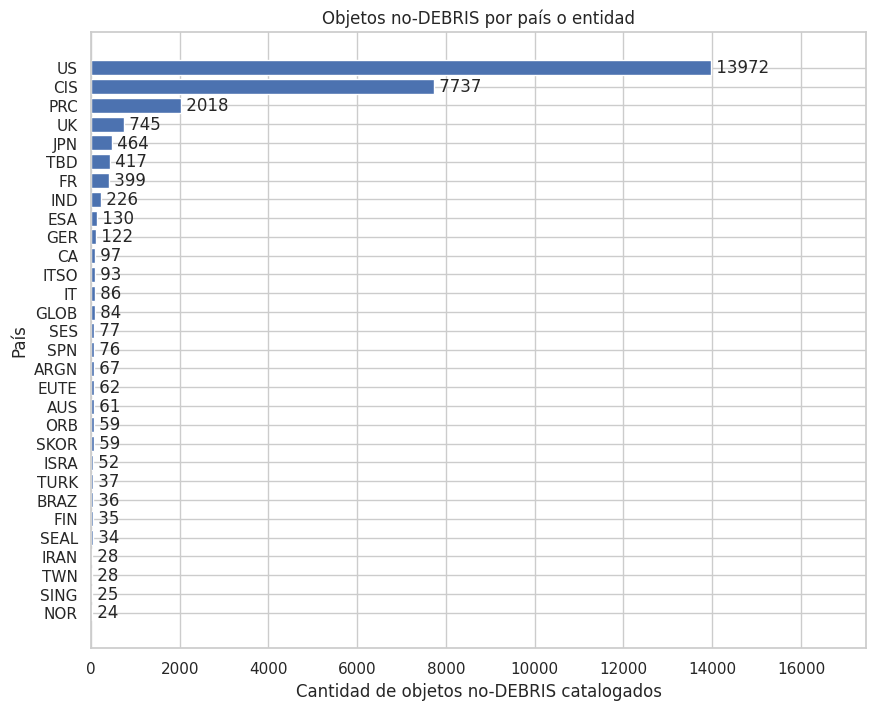

In [32]:
objs_per_country_no_debris_df = space_objects_df[space_objects_df['OBJECT_TYPE'] != 'DEBRIS'] \
    .groupby("COUNTRY") \
    .count() \
    .sort_values("OBJECT_ID", ascending=False) \
    .head(n=30) \
    .sort_values("OBJECT_ID", ascending=True)

plot_ranking(
    xseries=objs_per_country_no_debris_df.OBJECT_ID,
    yseries=objs_per_country_no_debris_df.index,
    xlabel="Cantidad de objetos no-DEBRIS catalogados",
    ylabel="País",
    title="Objetos no-DEBRIS por país o entidad")


Al excluir DEBRIS, US tiene el mayor conteo. El cambio de orden respecto del catálogo completo muestra diferencias en la composición por tipo de objeto. No permite comparar cantidades de satélites operativos.

Desagregamos los tres países o entidades con más registros no-DEBRIS.


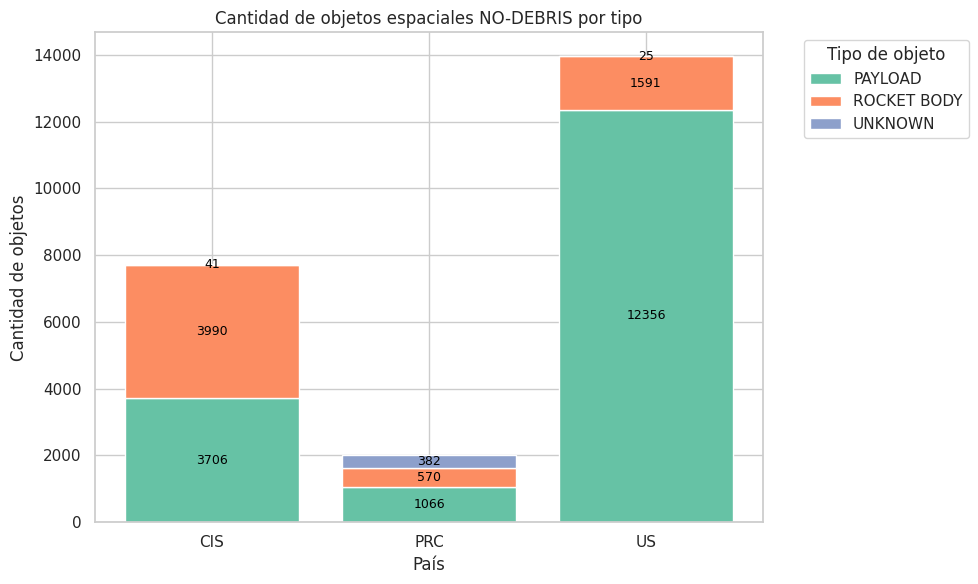

In [33]:
top3_countries = objs_per_country_no_debris_df.tail(3).index.tolist()

grouped_top3_df = (
    space_objects_df[
        (space_objects_df['OBJECT_TYPE'] != 'DEBRIS') &
        (space_objects_df['COUNTRY'].isin(top3_countries))
    ]
    .groupby(['COUNTRY', 'OBJECT_TYPE'])
    .size()
    .reset_index(name='Cantidad')
)

pivot_df = grouped_top3_df.pivot(index='COUNTRY', columns='OBJECT_TYPE', values='Cantidad').fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.get_cmap('Set2').colors

bottom = [0] * len(pivot_df)
for i, column in enumerate(pivot_df.columns):
    values = pivot_df[column].values
    bars = ax.bar(pivot_df.index, values, bottom=bottom, label=column, color=colors[i % len(colors)])

    for j, value in enumerate(values):
        if value > 0:
            ax.text(j, bottom[j] + value / 2, int(value), ha='center', va='center', fontsize=9, color='black')

    bottom = [bottom[k] + values[k] for k in range(len(values))]

ax.set_title('Cantidad de objetos espaciales NO-DEBRIS por tipo')
ax.set_xlabel('País')
ax.set_ylabel('Cantidad de objetos')
ax.legend(title='Tipo de objeto', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

US está dominado por PAYLOAD, mientras que CIS presenta un conteo importante de ROCKET BODY. PRC tiene más UNKNOWN que los otros dos grupos mostrados.

Las categorías describen el tipo registrado: PAYLOAD no garantiza actividad; ROCKET BODY identifica cuerpos de cohete; UNKNOWN indica que no se dispone de una clasificación de tipo. Estas diferencias no demuestran por sí solas qué misiones o constelaciones explican los conteos.


### Objetos catalogados por año de lanzamiento asociado


Agrupamos las filas por `LAUNCH_YEAR`. Un mismo lanzamiento puede corresponder a múltiples cargas, cuerpos de cohete y fragmentos catalogados. Por eso, **el eje vertical cuenta objetos, no eventos de lanzamiento**. Para DEBRIS, tampoco representa la fecha de generación del fragmento.

La serie no reconstruye cuántos objetos había en órbita cada año; esa pregunta requiere considerar entradas, reentradas y, para fragmentos, fechas de creación. El último año del dataset puede ser parcial.


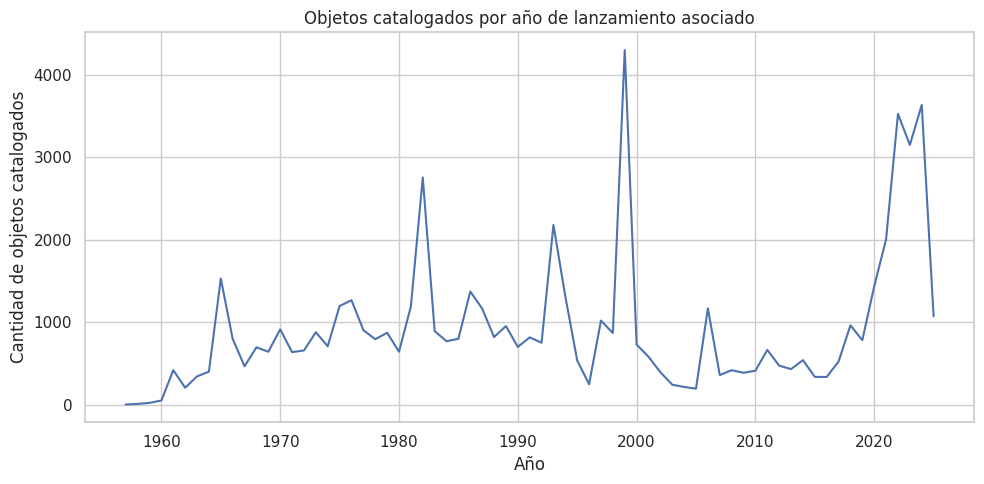

In [34]:
space_objects_df['LAUNCH_YEAR'].value_counts().sort_index().plot(figsize=(10,5))
plt.title("Objetos catalogados por año de lanzamiento asociado")
plt.xlabel("Año")
plt.ylabel("Cantidad de objetos catalogados")

plt.tight_layout()
plt.show()


La serie presenta varios picos y un aumento en cohortes recientes. Para interpretar su composición, separamos las filas por tipo de objeto; no atribuimos los picos a eventos concretos sin una identificación adicional.


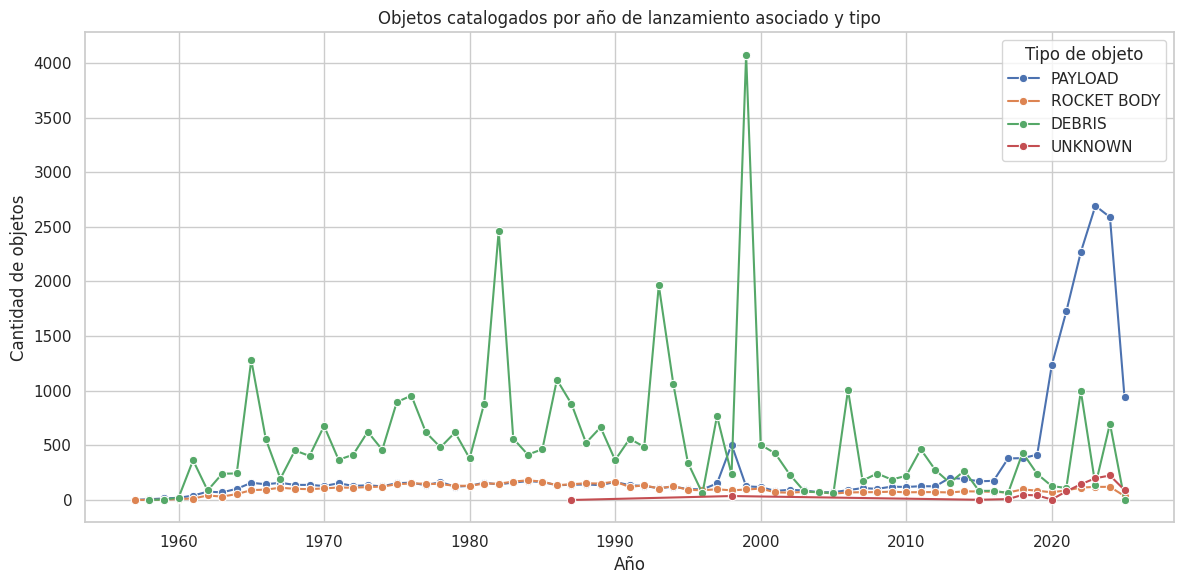

In [35]:
# Agrupar por año y tipo de objeto
launches_by_year_and_type_df = (
    space_objects_df.groupby(['LAUNCH_YEAR', 'OBJECT_TYPE'])
    .size()
    .reset_index(name='count')
)

# Gráfico de líneas
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=launches_by_year_and_type_df,
    x='LAUNCH_YEAR',
    y='count',
    hue='OBJECT_TYPE',
    marker='o'
)

plt.title("Objetos catalogados por año de lanzamiento asociado y tipo")
plt.xlabel("Año")
plt.ylabel("Cantidad de objetos")
plt.legend(title='Tipo de objeto')
plt.tight_layout()
plt.show()


DEBRIS tiene un peso importante en varias cohortes antiguas y PAYLOAD aumenta en las cohortes recientes. Esto no significa que cada satélite antiguo se haya transformado en un registro DEBRIS: las filas corresponden a objetos distintos, y un solo objeto progenitor puede originar muchos fragmentos.


Comparamos los registros asociados a CIS y US, primero para todos los tipos y luego sólo PAYLOAD.


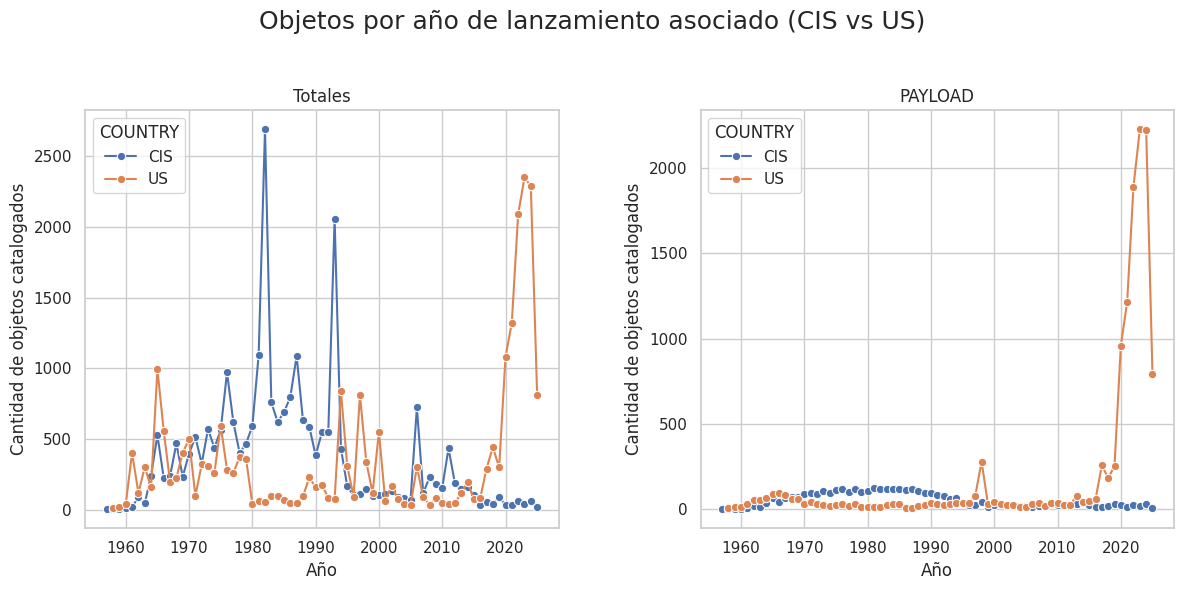

In [36]:
# Filtramos sólo CIS y US
cis_and_us_df = space_objects_df[space_objects_df['COUNTRY'].isin(['CIS', 'US'])]

# Vemos también únicamente satelites
satellites_only_df = space_objects_df[space_objects_df['OBJECT_TYPE'] == 'PAYLOAD']
cis_and_us_satellites_df = satellites_only_df[satellites_only_df['COUNTRY'].isin(['CIS', 'US'])]

# Agrupamos ambos por año y país
total_launches_by_year_country_df = (
    cis_and_us_df.groupby(['LAUNCH_YEAR', 'COUNTRY'])
    .size()
    .reset_index(name='count')
    .sort_values('LAUNCH_YEAR')
)
satellites_launches_by_year_country_df = (
    cis_and_us_satellites_df.groupby(['LAUNCH_YEAR', 'COUNTRY'])
    .size()
    .reset_index(name='count')
    .sort_values('LAUNCH_YEAR')
)

# Graficamos
fig, axes = plt.subplots(ncols=2,nrows=1, figsize=(12,6))
plt.suptitle('Objetos por año de lanzamiento asociado (CIS vs US)', fontsize=18)
sns.lineplot(
    data=total_launches_by_year_country_df,
    x='LAUNCH_YEAR',
    y='count',
    hue='COUNTRY',
    marker='o',
    ax=axes[0]
)

sns.lineplot(
    data=satellites_launches_by_year_country_df,
    x='LAUNCH_YEAR',
    y='count',
    hue='COUNTRY',
    marker='o',
    ax=axes[1]
)

axes[0].set_title("Totales")
axes[1].set_title("PAYLOAD")

axes[0].set_ylabel("Cantidad de objetos catalogados")
axes[1].set_ylabel("Cantidad de objetos catalogados")

axes[0].set_xlabel("Año")
axes[1].set_xlabel("Año")

plt.tight_layout(rect=[0, 0, 1, 0.95], w_pad=4)
plt.show()


US presenta un aumento de PAYLOAD en las cohortes recientes; CIS muestra picos históricos en el conjunto de todos los tipos. La magnitud de los picos depende de la composición del catálogo y no equivale a cantidad de lanzamientos.

Conservamos la ventana 1957–1975 del trabajo original para explorar el período de la carrera espacial. Los hitos anotados sirven como contexto, no como explicación causal de las curvas.


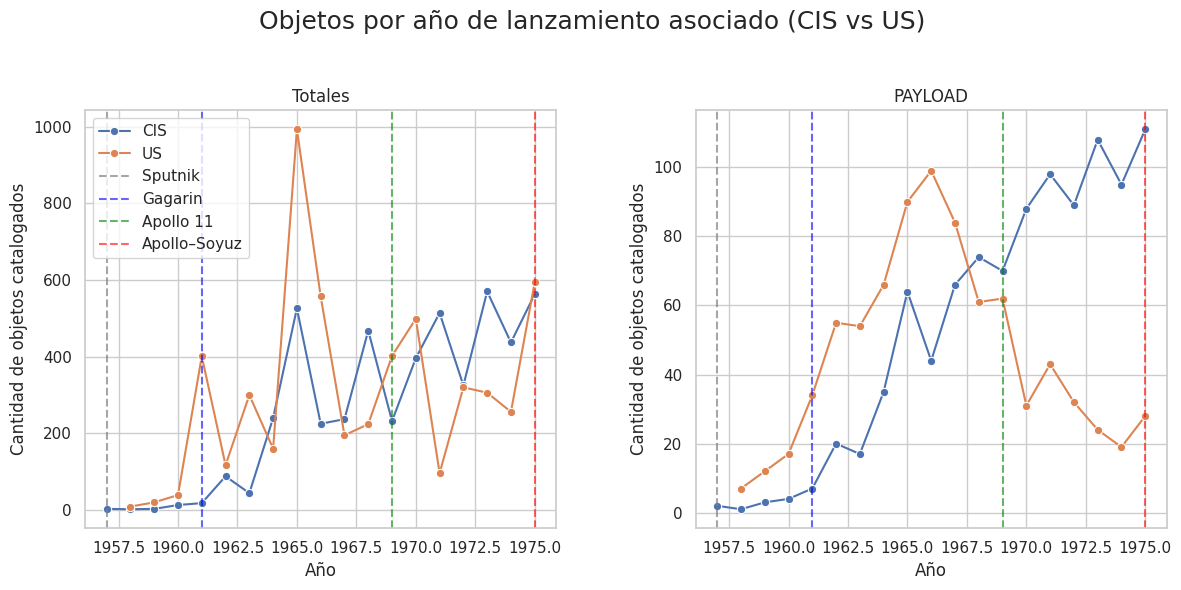

In [37]:
# Aplicamos máscara sobre cada DataFrame
space_race_df = cis_and_us_df[
    (cis_and_us_df['LAUNCH_YEAR'] >= 1957) & (cis_and_us_df['LAUNCH_YEAR'] <= 1975)
]

space_race_satellites_only_df = cis_and_us_satellites_df[
    (cis_and_us_satellites_df['LAUNCH_YEAR'] >= 1957) & (cis_and_us_satellites_df['LAUNCH_YEAR'] <= 1975)
]

# Agrupamos ambos por año y país
total_launches_by_year_country_time = (
    space_race_df.groupby(['LAUNCH_YEAR', 'COUNTRY'])
    .size()
    .reset_index(name='count')
    .sort_values('LAUNCH_YEAR')
)
satellites_launches_by_year_country_time = (
    space_race_satellites_only_df.groupby(['LAUNCH_YEAR', 'COUNTRY'])
    .size()
    .reset_index(name='count')
    .sort_values('LAUNCH_YEAR')
)

# Graficamos
fig, axes = plt.subplots(ncols=2,nrows=1, figsize=(12,6))
plt.suptitle('Objetos por año de lanzamiento asociado (CIS vs US)', fontsize=18)
sns.lineplot(
    data=total_launches_by_year_country_time,
    x='LAUNCH_YEAR',
    y='count',
    hue='COUNTRY',
    marker='o',
    ax=axes[0]
)

sns.lineplot(
    data=satellites_launches_by_year_country_time,
    x='LAUNCH_YEAR',
    y='count',
    hue='COUNTRY',
    marker='o',
    ax=axes[1]
)

# Agregamos líneas verticales con etiquetas de eventos históricos
for ax in axes:
    ax.axvline(x=1957, color='gray', linestyle='--', alpha=0.7, label='Sputnik')
    ax.axvline(x=1961, color='blue', linestyle='--', alpha=0.6, label='Gagarin')
    ax.axvline(x=1969, color='green', linestyle='--', alpha=0.6, label='Apollo 11')
    ax.axvline(x=1975, color='red', linestyle='--', alpha=0.6, label='Apollo–Soyuz')
    ax.legend()

axes[0].set_title("Totales")
axes[1].set_title("PAYLOAD")

axes[0].set_ylabel("Cantidad de objetos catalogados")
axes[1].set_ylabel("Cantidad de objetos catalogados")

axes[0].set_xlabel("Año")
axes[1].set_xlabel("Año")

# Agregamos la leyenda unicamente en un grafico
axes[0].legend(loc='upper left')
axes[1].legend().remove()

plt.tight_layout(rect=[0, 0, 1, 0.95], w_pad=4)
plt.show()


Las líneas señalan los hitos históricos utilizados en el trabajo original: Sputnik (1957), el vuelo de Gagarin (1961), Apollo 11 (1969) y Apollo–Soyuz (1975). Su coincidencia visual con los datos no demuestra que hayan producido los máximos observados.


La comparación describe objetos catalogados asociados a lanzamientos de cada año, incluyendo fragmentos que pudieron originarse después. Por lo tanto, estas curvas no permiten concluir por sí solas quién lideró en número de lanzamientos, inversión o generación de basura durante la carrera espacial.


## Conclusiones y próximos pasos

- El catálogo histórico reúne 63.521 objetos y combina registros con y sin reentrada informada. DEBRIS representa aproximadamente el 56% de las filas, sin equivaler a toda la población actual de residuos en órbita.
- La unión con UCS conserva las filas y documenta su cobertura y conflictos de clasificación. Las fuentes complementarias no cubren de forma uniforme los distintos tipos de objeto.
- Los rangos de perigeo y las categorías radar permiten describir patrones, con límites explícitos: no sustituyen una clasificación orbital completa ni una medición física directa de tamaño.
- Los conteos por año describen cohortes de lanzamiento asociadas a registros. No son tasas de lanzamientos ni de generación de fragmentos.

En la siguiente etapa de curación se deberá definir la población de modelado, revisar los faltantes y discrepancias entre fuentes y documentar el significado de la variable objetivo. En particular, una vida útil esperada no debe interpretarse automáticamente como tiempo hasta reentrada.
